
#  **mobile_behavior_analysis**

In [1]:
# @title Setup - Install relevant modules
!pip install matplotlib
!pip install pandas
!pip install scikit-learn
!pip install seaborn

In [2]:
# @title Setup - Import relevant modules
import pandas as pd
from matplotlib import pyplot as plt
import io
import numpy as np
import seaborn as sns

instead of importing the file , as it was very small csv file i chose to use a io library which would remove the need of downloading the file locally

In [3]:
# @title Defining the dataset
df = '''User ID,Device Model,Operating System,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age,Gender,User Behavior Class
1,Google Pixel 5,Android,393,6.4,1872,67,1122,40,Male,4
2,OnePlus 9,Android,268,4.7,1331,42,944,47,Female,3
3,Xiaomi Mi 11,Android,154,4.0,761,32,322,42,Male,2
4,Google Pixel 5,Android,239,4.8,1676,56,871,20,Male,3
5,iPhone 12,iOS,187,4.3,1367,58,988,31,Female,3
6,Google Pixel 5,Android,99,2.0,940,35,564,31,Male,2
7,Samsung Galaxy S21,Android,350,7.3,1802,66,1054,21,Female,4
8,OnePlus 9,Android,543,11.4,2956,82,1702,31,Male,5
9,Samsung Galaxy S21,Android,340,7.7,2138,75,1053,42,Female,4
10,iPhone 12,iOS,424,6.6,1957,75,1301,42,Male,4
11,Google Pixel 5,Android,53,1.4,435,17,162,34,Female,1
12,OnePlus 9,Android,215,5.5,1690,47,641,24,Male,3
13,OnePlus 9,Android,462,6.2,2303,65,1099,57,Female,4
14,Xiaomi Mi 11,Android,215,4.9,1662,43,857,43,Male,3
15,iPhone 12,iOS,189,5.4,1754,53,779,49,Female,3
16,Google Pixel 5,Android,503,10.4,2571,84,2025,39,Female,5
17,OnePlus 9,Android,132,3.6,628,32,344,47,Female,2
18,iPhone 12,iOS,299,5.8,1431,41,985,44,Female,3
19,Google Pixel 5,Android,81,1.4,558,16,297,26,Female,1
20,iPhone 12,iOS,577,8.5,2774,89,2192,29,Female,5
21,Samsung Galaxy S21,Android,93,2.6,681,37,302,45,Female,2
22,OnePlus 9,Android,576,11.6,2803,82,1553,43,Female,5
23,Samsung Galaxy S21,Android,423,6.5,2094,65,1372,23,Female,4
24,Google Pixel 5,Android,292,5.6,1401,46,949,37,Female,3
25,OnePlus 9,Android,216,4.0,1711,59,748,58,Male,3
26,Samsung Galaxy S21,Android,91,3.4,1073,38,451,52,Male,2
27,iPhone 12,iOS,444,7.6,2372,77,1002,29,Male,4
28,Google Pixel 5,Android,512,10.5,2409,89,1599,33,Male,5
29,OnePlus 9,Android,452,6.8,2387,77,1456,55,Female,4
30,Samsung Galaxy S21,Android,412,6.2,1899,78,1384,19,Female,4
31,Xiaomi Mi 11,Android,260,6.0,1361,44,889,37,Female,3
32,Xiaomi Mi 11,Android,197,4.6,1660,59,975,25,Male,3
33,Google Pixel 5,Android,278,4.7,1484,55,917,21,Male,3
34,Google Pixel 5,Android,46,2.0,457,14,105,58,Male,1
35,Xiaomi Mi 11,Android,593,10.2,2499,81,1616,38,Female,5
36,Samsung Galaxy S21,Android,32,1.2,580,19,153,20,Female,1
37,iPhone 12,iOS,122,3.3,755,30,573,26,Male,2
38,Samsung Galaxy S21,Android,522,11.2,2808,93,2328,24,Male,5
39,OnePlus 9,Android,473,6.4,2312,74,1400,40,Male,4
40,Samsung Galaxy S21,Android,398,6.2,1851,77,1180,23,Male,4
41,Xiaomi Mi 11,Android,240,4.7,1464,52,708,56,Female,3
42,OnePlus 9,Android,576,10.1,2447,83,2323,33,Male,5
43,Samsung Galaxy S21,Android,120,2.1,720,39,392,43,Male,2
44,Samsung Galaxy S21,Android,152,3.7,993,32,429,18,Male,2
45,Xiaomi Mi 11,Android,138,2.4,837,21,572,56,Female,2
46,Xiaomi Mi 11,Android,502,10.9,2476,96,1935,39,Male,5
47,OnePlus 9,Android,558,8.4,2447,97,1594,22,Female,5
48,Samsung Galaxy S21,Android,138,3.6,889,25,323,27,Female,2
49,Google Pixel 5,Android,580,8.2,2623,90,2262,49,Male,5
50,OnePlus 9,Android,589,8.7,2736,82,1997,49,Male,5
51,Xiaomi Mi 11,Android,452,7.4,2180,61,1417,54,Female,4
52,Xiaomi Mi 11,Android,245,5.9,1243,52,885,29,Male,3
53,Samsung Galaxy S21,Android,125,2.7,690,28,393,27,Female,2
54,Xiaomi Mi 11,Android,97,2.2,1101,38,375,53,Male,2
55,Google Pixel 5,Android,516,8.7,2857,83,2189,53,Female,5
56,iPhone 12,iOS,68,1.6,450,14,111,30,Male,1
57,OnePlus 9,Android,64,1.1,572,10,161,42,Female,1
58,OnePlus 9,Android,539,8.4,2796,89,2415,26,Male,5
59,Xiaomi Mi 11,Android,428,7.0,2306,75,1144,22,Male,4
60,iPhone 12,iOS,325,7.1,2269,64,1053,56,Male,4
61,Xiaomi Mi 11,Android,522,11.9,2798,85,1663,28,Female,5
62,Xiaomi Mi 11,Android,309,7.5,2292,77,1253,57,Female,4
63,Xiaomi Mi 11,Android,79,1.9,493,14,128,55,Male,1
64,Xiaomi Mi 11,Android,545,11.5,2911,87,1717,21,Female,5
65,Samsung Galaxy S21,Android,459,7.0,1982,67,1091,43,Male,4
66,iPhone 12,iOS,225,4.0,1420,48,917,56,Male,3
67,iPhone 12,iOS,257,4.5,1705,57,912,55,Male,3
68,Xiaomi Mi 11,Android,134,4.0,773,35,449,28,Female,2
69,iPhone 12,iOS,516,10.2,2932,98,1547,31,Male,5
70,Google Pixel 5,Android,82,1.7,558,16,284,29,Female,1
71,Samsung Galaxy S21,Android,452,7.2,1808,64,1090,45,Female,4
72,iPhone 12,iOS,521,9.0,2902,97,1701,37,Male,5
73,Google Pixel 5,Android,457,6.3,2347,66,1082,22,Male,4
74,Xiaomi Mi 11,Android,31,1.1,585,11,208,50,Female,1
75,iPhone 12,iOS,47,2.0,476,14,125,39,Male,1
76,Xiaomi Mi 11,Android,229,5.7,1305,43,985,23,Female,3
77,Xiaomi Mi 11,Android,34,2.0,558,14,122,54,Female,1
78,Google Pixel 5,Android,173,2.5,678,29,301,30,Female,2
79,Samsung Galaxy S21,Android,78,1.8,333,17,138,51,Female,1
80,Google Pixel 5,Android,230,5.7,1254,52,989,34,Female,3
81,OnePlus 9,Android,565,10.6,2475,99,1603,51,Female,5
82,iPhone 12,iOS,172,2.8,1035,22,549,41,Male,2
83,Xiaomi Mi 11,Android,330,7.2,2363,77,1133,21,Female,4
84,Xiaomi Mi 11,Android,39,1.8,368,11,105,19,Male,1
85,Google Pixel 5,Android,223,4.5,1311,56,695,33,Female,3
86,Google Pixel 5,Android,404,7.4,2081,63,1352,44,Male,4
87,Samsung Galaxy S21,Android,151,2.4,1003,25,392,39,Male,2
88,Samsung Galaxy S21,Android,34,1.5,345,11,276,44,Male,1
89,Xiaomi Mi 11,Android,137,3.3,839,31,348,34,Female,2
90,Samsung Galaxy S21,Android,301,6.2,2053,75,1303,45,Male,4
91,Google Pixel 5,Android,116,2.1,912,39,307,40,Female,2
92,Google Pixel 5,Android,291,4.1,1474,46,827,32,Female,3
93,iPhone 12,iOS,84,1.4,501,16,284,56,Female,1
94,iPhone 12,iOS,134,2.5,1125,24,367,35,Male,2
95,Samsung Galaxy S21,Android,411,7.5,2169,72,1083,58,Male,4
96,Xiaomi Mi 11,Android,326,7.2,2243,73,1454,50,Male,4
97,iPhone 12,iOS,550,9.5,2916,91,1946,20,Male,5
98,OnePlus 9,Android,516,12.0,2406,82,1968,28,Female,5
99,Google Pixel 5,Android,59,1.2,361,18,293,25,Female,1
100,OnePlus 9,Android,225,5.5,1526,44,875,50,Female,3
101,Google Pixel 5,Android,41,1.1,389,15,136,53,Male,1
102,OnePlus 9,Android,183,4.1,1210,45,738,19,Male,3
103,Google Pixel 5,Android,174,2.5,929,37,565,32,Female,2
104,Xiaomi Mi 11,Android,274,4.2,1781,52,934,28,Male,3
105,Xiaomi Mi 11,Android,166,2.8,1113,28,360,25,Male,2
106,Xiaomi Mi 11,Android,66,1.2,585,12,264,36,Male,1
107,Google Pixel 5,Android,152,2.7,642,38,596,55,Male,2
108,Google Pixel 5,Android,54,1.4,403,17,278,23,Female,1
109,Xiaomi Mi 11,Android,187,5.5,1754,55,711,50,Female,3
110,OnePlus 9,Android,216,6.0,1641,41,889,39,Female,3
111,OnePlus 9,Android,95,3.8,718,26,459,41,Female,2
112,Xiaomi Mi 11,Android,488,8.6,2447,84,2344,19,Male,5
113,Google Pixel 5,Android,295,5.1,1483,45,748,27,Female,3
114,Samsung Galaxy S21,Android,136,3.2,818,33,404,42,Male,2
115,Xiaomi Mi 11,Android,471,7.9,2156,76,1324,54,Female,4
116,iPhone 12,iOS,121,3.2,651,34,596,39,Male,2
117,iPhone 12,iOS,75,1.2,409,13,281,18,Male,1
118,iPhone 12,iOS,220,5.2,1631,49,909,27,Female,3
119,Samsung Galaxy S21,Android,82,1.6,590,13,124,28,Female,1
120,Google Pixel 5,Android,97,2.7,1018,37,428,41,Male,2
121,Samsung Galaxy S21,Android,388,6.6,2085,71,1150,45,Female,4
122,OnePlus 9,Android,529,8.7,2484,89,2189,39,Female,5
123,Google Pixel 5,Android,584,10.0,2541,99,2391,49,Female,5
124,Google Pixel 5,Android,529,8.1,2686,96,1924,35,Male,5
125,Google Pixel 5,Android,227,5.1,1702,57,714,21,Male,3
126,Samsung Galaxy S21,Android,535,11.8,2858,99,2378,50,Male,5
127,iPhone 12,iOS,332,7.4,2149,68,1321,20,Female,4
128,Google Pixel 5,Android,252,4.2,1439,45,667,50,Female,3
129,Xiaomi Mi 11,Android,125,2.5,678,34,465,31,Male,2
130,Xiaomi Mi 11,Android,97,3.3,751,39,412,36,Female,2
131,Google Pixel 5,Android,540,10.8,2923,90,1886,40,Male,5
132,Xiaomi Mi 11,Android,320,7.2,2056,69,1226,52,Female,4
133,Google Pixel 5,Android,176,3.6,1193,30,458,40,Female,2
134,Samsung Galaxy S21,Android,79,1.0,313,18,139,42,Male,1
135,Xiaomi Mi 11,Android,83,1.6,303,19,285,51,Male,1
136,iPhone 12,iOS,555,11.3,2528,90,1856,55,Female,5
137,Samsung Galaxy S21,Android,66,1.7,375,16,216,39,Male,1
138,Xiaomi Mi 11,Android,237,4.5,1368,42,868,24,Female,3
139,Samsung Galaxy S21,Android,497,9.7,2876,94,2076,18,Male,5
140,Google Pixel 5,Android,516,11.1,2429,91,1796,53,Male,5
141,Xiaomi Mi 11,Android,219,5.2,1510,42,655,50,Female,3
142,Google Pixel 5,Android,448,6.3,2044,71,1337,51,Male,4
143,iPhone 12,iOS,156,2.2,896,37,429,57,Female,2
144,Samsung Galaxy S21,Android,68,1.1,528,12,201,29,Male,1
145,iPhone 12,iOS,524,11.2,2417,90,2069,29,Female,5
146,iPhone 12,iOS,188,5.3,1281,45,974,35,Male,3
147,Samsung Galaxy S21,Android,443,7.4,2289,73,1026,33,Male,4
148,Xiaomi Mi 11,Android,52,1.6,385,19,234,24,Male,1
149,OnePlus 9,Android,228,4.2,1677,58,823,56,Male,3
150,Google Pixel 5,Android,149,3.7,873,34,459,51,Male,2
151,iPhone 12,iOS,523,9.4,2583,92,1539,21,Male,5
152,Samsung Galaxy S21,Android,42,1.6,315,19,207,52,Female,1
153,Google Pixel 5,Android,120,2.0,741,38,396,56,Female,2
154,OnePlus 9,Android,329,7.5,2277,72,1185,27,Female,4
155,Xiaomi Mi 11,Android,68,1.5,364,10,102,31,Female,1
156,Xiaomi Mi 11,Android,158,3.4,893,36,493,32,Male,2
157,Xiaomi Mi 11,Android,86,1.7,439,19,136,54,Male,1
158,Xiaomi Mi 11,Android,339,7.8,2102,71,1062,51,Male,4
159,Samsung Galaxy S21,Android,304,6.5,2375,79,1493,51,Male,4
160,Xiaomi Mi 11,Android,131,2.4,859,26,305,40,Male,2
161,Samsung Galaxy S21,Android,64,1.6,540,19,262,35,Female,1
162,Xiaomi Mi 11,Android,53,1.9,526,15,112,42,Male,1
163,Google Pixel 5,Android,442,7.7,2067,69,1440,45,Male,4
164,iPhone 12,iOS,32,2.0,469,18,139,22,Male,1
165,Xiaomi Mi 11,Android,278,4.8,1238,48,851,43,Female,3
166,Xiaomi Mi 11,Android,540,8.4,2993,98,1540,49,Female,5
167,Google Pixel 5,Android,595,11.3,2968,88,2366,30,Male,5
168,Google Pixel 5,Android,35,1.5,467,10,158,58,Male,1
169,Google Pixel 5,Android,225,5.4,1370,44,791,55,Female,3
170,Google Pixel 5,Android,587,11.8,2431,90,1894,47,Male,5
171,Xiaomi Mi 11,Android,92,3.7,1124,27,524,44,Male,2
172,Google Pixel 5,Android,46,1.1,487,17,208,23,Male,1
173,OnePlus 9,Android,153,2.8,935,25,578,37,Female,2
174,iPhone 12,iOS,368,6.6,1817,72,1406,27,Female,4
175,Xiaomi Mi 11,Android,51,1.6,509,11,113,29,Female,1
176,Google Pixel 5,Android,279,5.2,1660,47,629,50,Female,3
177,Xiaomi Mi 11,Android,255,5.4,1738,42,826,21,Male,3
178,Samsung Galaxy S21,Android,193,5.7,1471,51,972,31,Female,3
179,Xiaomi Mi 11,Android,207,5.7,1582,52,692,38,Male,3
180,iPhone 12,iOS,539,11.9,2853,83,2007,55,Male,5
181,OnePlus 9,Android,151,2.4,1124,38,571,33,Male,2
182,Google Pixel 5,Android,474,6.4,2109,68,1079,24,Male,4
183,iPhone 12,iOS,544,9.2,2936,83,2416,47,Female,5
184,iPhone 12,iOS,73,1.2,308,15,275,39,Female,1
185,Xiaomi Mi 11,Android,597,10.4,2984,91,1564,34,Female,5
186,Google Pixel 5,Android,498,10.7,2738,94,1995,42,Male,5
187,iPhone 12,iOS,402,7.8,2014,79,1088,34,Female,4
188,OnePlus 9,Android,75,1.1,379,15,185,37,Male,1
189,iPhone 12,iOS,130,2.0,602,21,589,30,Female,2
190,Samsung Galaxy S21,Android,42,1.1,402,11,265,32,Female,1
191,iPhone 12,iOS,134,2.2,917,23,423,23,Male,2
192,Google Pixel 5,Android,79,1.9,477,13,161,24,Male,1
193,iPhone 12,iOS,432,7.2,1822,63,1127,59,Female,4
194,iPhone 12,iOS,262,4.1,1287,52,997,36,Male,3
195,Samsung Galaxy S21,Android,473,6.4,2109,79,1300,23,Female,4
196,Google Pixel 5,Android,202,4.7,1512,49,659,45,Female,3
197,OnePlus 9,Android,215,4.4,1407,41,991,47,Male,3
198,OnePlus 9,Android,151,3.7,1116,32,320,41,Female,2
199,OnePlus 9,Android,80,1.6,549,14,197,19,Male,1
200,Xiaomi Mi 11,Android,126,2.8,971,32,431,35,Female,2
201,Samsung Galaxy S21,Android,495,8.9,2920,84,2252,31,Female,5
202,iPhone 12,iOS,127,3.7,1153,35,314,37,Female,2
203,Xiaomi Mi 11,Android,88,1.3,327,11,262,22,Male,1
204,Google Pixel 5,Android,69,1.6,463,16,146,27,Male,1
205,OnePlus 9,Android,100,3.3,961,21,433,25,Male,2
206,Xiaomi Mi 11,Android,301,6.5,2084,71,1421,29,Male,4
207,Google Pixel 5,Android,78,1.7,455,15,207,37,Female,1
208,Google Pixel 5,Android,163,3.1,620,21,419,23,Male,2
209,OnePlus 9,Android,539,9.3,2606,92,1990,41,Male,5
210,Google Pixel 5,Android,278,4.6,1385,47,823,40,Female,3
211,Samsung Galaxy S21,Android,451,6.1,2108,76,1434,25,Female,4
212,Samsung Galaxy S21,Android,481,10.9,2752,86,2017,18,Male,5
213,Samsung Galaxy S21,Android,133,3.4,714,38,445,25,Male,2
214,Xiaomi Mi 11,Android,41,1.1,588,10,246,22,Male,1
215,iPhone 12,iOS,152,3.3,1175,29,461,42,Female,2
216,OnePlus 9,Android,553,8.4,2559,89,2471,51,Male,5
217,iPhone 12,iOS,402,6.9,2282,78,1397,40,Male,4
218,OnePlus 9,Android,555,9.5,2855,95,1565,24,Male,5
219,iPhone 12,iOS,499,9.6,2873,81,1805,52,Female,5
220,Xiaomi Mi 11,Android,101,3.2,603,28,417,43,Male,2
221,OnePlus 9,Android,433,6.8,2093,75,1300,32,Male,4
222,OnePlus 9,Android,133,2.0,1007,31,417,32,Male,2
223,Xiaomi Mi 11,Android,351,6.1,1941,79,1290,21,Female,4
224,Samsung Galaxy S21,Android,532,10.7,2556,83,2148,53,Female,5
225,OnePlus 9,Android,92,2.5,690,31,563,27,Male,2
226,Xiaomi Mi 11,Android,511,10.8,2712,97,2438,59,Female,5
227,Xiaomi Mi 11,Android,384,7.0,2185,72,1376,59,Male,4
228,iPhone 12,iOS,193,5.2,1318,49,626,32,Female,3
229,Samsung Galaxy S21,Android,132,3.8,649,25,368,41,Male,2
230,Samsung Galaxy S21,Android,360,7.3,1946,79,1164,50,Male,4
231,iPhone 12,iOS,159,2.3,1083,32,526,38,Male,2
232,iPhone 12,iOS,495,8.9,2855,91,2150,31,Male,5
233,Xiaomi Mi 11,Android,537,10.0,2720,83,1763,35,Male,5
234,OnePlus 9,Android,129,3.4,1059,27,580,36,Female,2
235,iPhone 12,iOS,132,3.8,636,28,529,53,Male,2
236,Xiaomi Mi 11,Android,37,1.4,369,18,295,19,Female,1
237,Samsung Galaxy S21,Android,524,8.9,2549,88,1730,20,Female,5
238,OnePlus 9,Android,425,6.9,2142,66,1130,19,Female,4
239,OnePlus 9,Android,64,1.7,585,13,107,53,Male,1
240,iPhone 12,iOS,573,10.8,2711,96,2118,33,Female,5
241,Google Pixel 5,Android,45,1.7,302,16,191,57,Female,1
242,Xiaomi Mi 11,Android,564,11.7,2764,81,2133,37,Female,5
243,OnePlus 9,Android,162,3.5,761,36,338,51,Male,2
244,Samsung Galaxy S21,Android,451,6.5,2378,69,1341,44,Male,4
245,OnePlus 9,Android,30,1.3,479,16,253,35,Male,1
246,Samsung Galaxy S21,Android,202,5.0,1542,45,844,29,Male,3
247,Google Pixel 5,Android,71,1.5,590,17,257,33,Male,1
248,Google Pixel 5,Android,314,6.2,2205,63,1066,19,Male,4
249,Xiaomi Mi 11,Android,168,4.0,866,22,581,50,Female,2
250,Google Pixel 5,Android,75,1.9,537,13,230,58,Female,1
251,OnePlus 9,Android,42,1.4,324,13,272,29,Female,1
252,OnePlus 9,Android,441,7.9,2332,78,1477,23,Female,4
253,Google Pixel 5,Android,523,10.5,2460,99,1787,22,Male,5
254,Xiaomi Mi 11,Android,100,2.4,982,31,478,48,Female,2
255,OnePlus 9,Android,52,1.2,398,14,172,24,Female,1
256,OnePlus 9,Android,397,7.0,2352,77,1101,46,Female,4
257,Xiaomi Mi 11,Android,424,7.7,1863,65,1116,52,Male,4
258,Xiaomi Mi 11,Android,272,5.0,1655,45,686,19,Female,3
259,Xiaomi Mi 11,Android,201,4.0,1791,50,914,18,Male,3
260,Xiaomi Mi 11,Android,570,9.0,2613,98,2497,49,Female,5
261,Xiaomi Mi 11,Android,64,1.3,490,14,151,43,Female,1
262,iPhone 12,iOS,334,6.6,2394,68,1227,46,Female,4
263,iPhone 12,iOS,518,9.6,2954,93,2125,34,Female,5
264,Samsung Galaxy S21,Android,70,1.7,359,10,109,57,Male,1
265,iPhone 12,iOS,334,6.8,2000,77,1079,40,Female,4
266,Xiaomi Mi 11,Android,563,8.4,2849,85,1508,25,Male,5
267,iPhone 12,iOS,181,4.1,1608,43,752,22,Female,3
268,OnePlus 9,Android,584,9.4,2766,84,2151,32,Male,5
269,Samsung Galaxy S21,Android,208,4.7,1642,45,861,55,Male,3
270,Samsung Galaxy S21,Android,381,6.6,2160,69,1450,20,Male,4
271,Xiaomi Mi 11,Android,426,6.5,1969,78,1266,53,Female,4
272,OnePlus 9,Android,284,4.2,1360,56,888,51,Male,3
273,Google Pixel 5,Android,105,2.2,1002,29,453,31,Female,2
274,Google Pixel 5,Android,179,2.3,1014,32,588,38,Male,2
275,iPhone 12,iOS,122,2.6,639,37,568,35,Male,2
276,OnePlus 9,Android,501,11.9,2702,88,1738,49,Male,5
277,Xiaomi Mi 11,Android,269,5.9,1666,42,629,32,Female,3
278,Google Pixel 5,Android,230,4.4,1607,52,878,54,Male,3
279,Xiaomi Mi 11,Android,85,1.6,417,12,122,47,Male,1
280,Samsung Galaxy S21,Android,411,7.8,2029,75,1136,33,Female,4
281,Samsung Galaxy S21,Android,73,1.7,403,12,163,51,Male,1
282,Xiaomi Mi 11,Android,39,1.7,530,11,268,26,Female,1
283,iPhone 12,iOS,386,7.7,2114,72,1209,51,Male,4
284,Google Pixel 5,Android,49,1.3,542,16,169,54,Female,1
285,Google Pixel 5,Android,411,6.9,1820,70,1024,43,Male,4
286,OnePlus 9,Android,534,10.8,2805,90,1538,37,Male,5
287,Samsung Galaxy S21,Android,314,7.4,2136,64,1376,47,Female,4
288,Xiaomi Mi 11,Android,211,4.0,1519,54,811,29,Female,3
289,OnePlus 9,Android,121,3.7,619,36,473,47,Male,2
290,Google Pixel 5,Android,84,1.2,415,10,146,50,Male,1
291,OnePlus 9,Android,448,7.6,2199,66,1047,28,Male,4
292,Google Pixel 5,Android,55,1.6,360,19,149,30,Male,1
293,Google Pixel 5,Android,59,1.8,497,10,208,36,Female,1
294,Xiaomi Mi 11,Android,226,4.5,1781,45,649,27,Female,3
295,Samsung Galaxy S21,Android,580,8.5,2660,87,1795,52,Male,5
296,OnePlus 9,Android,65,1.8,481,18,130,41,Male,1
297,OnePlus 9,Android,458,6.6,2214,67,1163,31,Female,4
298,iPhone 12,iOS,170,2.7,805,26,344,53,Female,2
299,iPhone 12,iOS,264,5.2,1641,44,778,44,Male,3
300,Xiaomi Mi 11,Android,122,3.3,748,35,499,59,Female,2
301,Xiaomi Mi 11,Android,420,6.5,2113,65,1314,35,Male,4
302,iPhone 12,iOS,267,4.4,1505,59,971,38,Female,3
303,iPhone 12,iOS,469,6.0,2290,67,1086,34,Female,4
304,iPhone 12,iOS,541,11.4,2443,89,1923,34,Female,5
305,iPhone 12,iOS,155,2.9,1117,22,322,19,Female,2
306,OnePlus 9,Android,106,2.8,686,32,594,27,Male,2
307,OnePlus 9,Android,243,5.0,1232,47,877,43,Male,3
308,OnePlus 9,Android,410,7.5,2176,68,1213,45,Female,4
309,iPhone 12,iOS,285,5.1,1226,57,666,20,Female,3
310,OnePlus 9,Android,397,6.8,2027,66,1167,40,Male,4
311,Samsung Galaxy S21,Android,230,4.2,1507,51,868,25,Female,3
312,iPhone 12,iOS,341,7.2,2397,68,1055,32,Female,4
313,Google Pixel 5,Android,132,2.9,1054,32,563,20,Male,2
314,Xiaomi Mi 11,Android,130,3.0,820,21,308,49,Female,2
315,iPhone 12,iOS,281,4.9,1566,59,632,29,Male,3
316,OnePlus 9,Android,74,2.0,320,11,103,55,Female,1
317,OnePlus 9,Android,299,4.3,1737,43,953,42,Female,3
318,Google Pixel 5,Android,116,2.2,827,29,434,28,Female,2
319,OnePlus 9,Android,408,6.6,2026,63,1076,47,Female,4
320,Google Pixel 5,Android,508,11.3,2590,81,2481,51,Male,5
321,iPhone 12,iOS,227,4.4,1275,56,984,22,Female,3
322,Google Pixel 5,Android,274,6.0,1489,56,666,57,Female,3
323,Google Pixel 5,Android,347,6.3,2001,61,1456,21,Female,4
324,Xiaomi Mi 11,Android,76,1.3,490,14,156,31,Female,1
325,iPhone 12,iOS,445,7.5,2007,78,1115,23,Male,4
326,OnePlus 9,Android,203,4.3,1554,54,638,25,Female,3
327,Samsung Galaxy S21,Android,199,6.0,1707,57,881,55,Male,3
328,OnePlus 9,Android,48,2.0,574,18,127,24,Female,1
329,OnePlus 9,Android,88,1.6,420,12,274,31,Female,1
330,iPhone 12,iOS,541,8.3,2865,89,1820,42,Female,5
331,Google Pixel 5,Android,233,4.6,1534,49,796,21,Female,3
332,iPhone 12,iOS,176,3.8,727,36,362,47,Female,2
333,OnePlus 9,Android,191,6.0,1762,45,904,54,Male,3
334,Google Pixel 5,Android,461,7.5,2001,69,1324,34,Female,4
335,Samsung Galaxy S21,Android,37,1.5,375,18,246,46,Female,1
336,OnePlus 9,Android,531,9.8,2905,99,1632,45,Female,5
337,Samsung Galaxy S21,Android,473,7.9,2292,62,1472,44,Male,4
338,Samsung Galaxy S21,Android,30,1.3,561,15,252,34,Male,1
339,iPhone 12,iOS,306,6.1,2267,70,1449,46,Male,4
340,iPhone 12,iOS,64,1.2,590,13,155,30,Male,1
341,iPhone 12,iOS,75,1.0,435,13,223,43,Male,1
342,iPhone 12,iOS,597,10.3,2718,90,1863,26,Female,5
343,iPhone 12,iOS,529,10.5,2971,87,1683,56,Male,5
344,iPhone 12,iOS,290,6.0,1533,54,645,57,Female,3
345,iPhone 12,iOS,256,5.8,1309,52,840,43,Male,3
346,iPhone 12,iOS,308,7.7,1974,73,1431,37,Female,4
347,OnePlus 9,Android,156,3.3,1020,38,447,57,Female,2
348,Samsung Galaxy S21,Android,62,1.4,542,18,266,46,Male,1
349,Google Pixel 5,Android,156,3.8,866,34,510,26,Male,2
350,Samsung Galaxy S21,Android,303,7.4,2314,66,1387,34,Male,4
351,Samsung Galaxy S21,Android,463,6.9,2111,73,1463,54,Male,4
352,Google Pixel 5,Android,60,1.5,593,14,281,35,Female,1
353,Google Pixel 5,Android,225,4.6,1230,52,954,20,Female,3
354,Samsung Galaxy S21,Android,379,7.5,1823,68,1075,53,Female,4
355,OnePlus 9,Android,53,1.4,455,14,106,54,Female,1
356,Samsung Galaxy S21,Android,30,1.9,574,19,287,45,Male,1
357,iPhone 12,iOS,291,4.1,1326,51,905,55,Female,3
358,iPhone 12,iOS,488,9.5,2840,92,1986,48,Female,5
359,Google Pixel 5,Android,74,2.0,366,13,253,44,Female,1
360,Samsung Galaxy S21,Android,230,4.6,1325,55,845,54,Female,3
361,Samsung Galaxy S21,Android,517,11.8,2435,86,2208,26,Male,5
362,OnePlus 9,Android,557,10.4,2900,97,1609,22,Male,5
363,Xiaomi Mi 11,Android,78,1.5,341,11,259,38,Female,1
364,iPhone 12,iOS,321,7.9,2159,64,1499,45,Male,4
365,Xiaomi Mi 11,Android,579,8.6,2539,84,1935,34,Male,5
366,OnePlus 9,Android,382,7.2,1965,67,1341,22,Male,4
367,Xiaomi Mi 11,Android,516,11.6,2464,82,1767,29,Female,5
368,OnePlus 9,Android,598,11.2,2876,85,2477,58,Female,5
369,OnePlus 9,Android,102,3.9,747,36,408,49,Female,2
370,iPhone 12,iOS,165,2.4,816,35,503,34,Male,2
371,iPhone 12,iOS,558,9.8,2765,83,1548,25,Female,5
372,Google Pixel 5,Android,561,10.6,2547,86,1823,22,Male,5
373,Samsung Galaxy S21,Android,511,10.9,2514,91,2335,59,Female,5
374,Google Pixel 5,Android,560,11.3,2947,95,1663,25,Female,5
375,OnePlus 9,Android,69,1.3,434,12,164,42,Male,1
376,OnePlus 9,Android,44,1.1,531,17,232,26,Male,1
377,iPhone 12,iOS,65,1.7,490,17,122,51,Female,1
378,Google Pixel 5,Android,458,6.0,1875,63,1072,31,Female,4
379,Samsung Galaxy S21,Android,525,10.8,2445,99,1623,57,Male,5
380,OnePlus 9,Android,106,3.0,922,22,313,51,Male,2
381,iPhone 12,iOS,188,4.6,1767,47,653,34,Male,3
382,iPhone 12,iOS,493,10.4,2453,99,1813,39,Male,5
383,OnePlus 9,Android,84,1.5,373,19,299,37,Female,1
384,OnePlus 9,Android,104,2.9,653,35,322,30,Male,2
385,Samsung Galaxy S21,Android,102,3.0,890,38,548,28,Male,2
386,iPhone 12,iOS,349,6.6,2041,78,1096,40,Female,4
387,OnePlus 9,Android,98,2.0,925,32,457,28,Male,2
388,Samsung Galaxy S21,Android,72,1.3,461,13,199,32,Male,1
389,Xiaomi Mi 11,Android,563,11.6,2968,92,2191,34,Female,5
390,Xiaomi Mi 11,Android,119,2.8,775,31,313,50,Female,2
391,OnePlus 9,Android,311,7.9,2231,69,1021,36,Male,4
392,OnePlus 9,Android,337,6.1,1901,76,1359,58,Male,4
393,Samsung Galaxy S21,Android,168,3.5,1055,29,313,54,Male,2
394,iPhone 12,iOS,331,7.4,2129,66,1459,53,Male,4
395,Google Pixel 5,Android,589,9.2,2663,84,1774,45,Female,5
396,Xiaomi Mi 11,Android,472,6.8,2288,61,1356,52,Male,4
397,Xiaomi Mi 11,Android,78,1.1,437,14,143,27,Female,1
398,iPhone 12,iOS,517,11.6,2798,90,2175,20,Male,5
399,OnePlus 9,Android,41,1.6,323,18,221,43,Female,1
400,OnePlus 9,Android,49,1.5,571,10,203,29,Male,1
401,Xiaomi Mi 11,Android,522,11.1,2821,86,1891,42,Male,5
402,Google Pixel 5,Android,97,2.7,612,36,508,53,Male,2
403,iPhone 12,iOS,411,7.4,1960,71,1264,40,Male,4
404,Samsung Galaxy S21,Android,566,8.6,2595,89,1657,51,Female,5
405,iPhone 12,iOS,559,8.2,2618,84,2102,22,Female,5
406,Google Pixel 5,Android,478,7.3,2340,69,1017,43,Female,4
407,Xiaomi Mi 11,Android,147,3.2,994,33,567,25,Female,2
408,OnePlus 9,Android,395,7.3,2291,61,1049,55,Female,4
409,Samsung Galaxy S21,Android,357,7.8,2289,74,1242,22,Female,4
410,Google Pixel 5,Android,405,6.9,2366,61,1434,51,Male,4
411,Samsung Galaxy S21,Android,501,11.8,2790,86,2074,31,Female,5
412,Xiaomi Mi 11,Android,575,8.2,2918,88,1928,50,Male,5
413,OnePlus 9,Android,257,5.1,1692,46,769,52,Female,3
414,iPhone 12,iOS,270,5.0,1532,51,957,35,Male,3
415,Google Pixel 5,Android,116,2.0,1171,22,573,33,Female,2
416,iPhone 12,iOS,98,2.3,608,24,394,56,Male,2
417,Xiaomi Mi 11,Android,264,5.1,1293,52,737,27,Female,3
418,Samsung Galaxy S21,Android,572,11.7,2655,91,2481,57,Female,5
419,Xiaomi Mi 11,Android,202,4.9,1549,43,964,27,Female,3
420,iPhone 12,iOS,83,1.4,454,11,228,46,Male,1
421,iPhone 12,iOS,32,1.4,416,12,198,56,Male,1
422,iPhone 12,iOS,168,3.2,716,38,414,43,Male,2
423,iPhone 12,iOS,416,6.1,2115,71,1041,22,Female,4
424,Xiaomi Mi 11,Android,46,1.1,536,18,167,28,Female,1
425,OnePlus 9,Android,201,5.0,1482,59,709,24,Male,3
426,Samsung Galaxy S21,Android,130,2.8,1062,24,579,37,Male,2
427,OnePlus 9,Android,98,2.4,747,36,403,44,Female,2
428,OnePlus 9,Android,105,3.8,967,28,489,51,Male,2
429,Xiaomi Mi 11,Android,94,2.3,1033,33,369,58,Male,2
430,Xiaomi Mi 11,Android,540,10.1,2757,90,2180,37,Male,5
431,iPhone 12,iOS,266,5.5,1238,59,839,22,Male,3
432,iPhone 12,iOS,140,3.8,1137,36,506,53,Male,2
433,Google Pixel 5,Android,534,10.4,2672,90,1702,51,Male,5
434,OnePlus 9,Android,46,2.0,309,15,116,42,Male,1
435,iPhone 12,iOS,581,8.4,2591,99,2304,58,Male,5
436,Xiaomi Mi 11,Android,105,3.4,798,21,467,34,Female,2
437,OnePlus 9,Android,221,4.4,1341,46,862,20,Male,3
438,iPhone 12,iOS,41,1.7,408,16,291,34,Male,1
439,OnePlus 9,Android,105,3.0,728,24,343,52,Female,2
440,Google Pixel 5,Android,123,3.9,915,39,468,18,Male,2
441,Google Pixel 5,Android,260,5.7,1725,56,920,36,Female,3
442,Samsung Galaxy S21,Android,223,5.7,1295,44,751,39,Male,3
443,Google Pixel 5,Android,66,1.1,505,17,218,33,Male,1
444,iPhone 12,iOS,231,4.0,1664,48,724,29,Female,3
445,iPhone 12,iOS,555,8.8,2540,97,2402,22,Male,5
446,Samsung Galaxy S21,Android,378,7.2,1859,61,1318,58,Male,4
447,OnePlus 9,Android,546,8.8,2852,81,1641,24,Male,5
448,Samsung Galaxy S21,Android,234,5.2,1604,58,919,58,Male,3
449,Samsung Galaxy S21,Android,152,3.0,617,22,306,22,Female,2
450,Google Pixel 5,Android,34,1.2,518,10,170,20,Female,1
451,Samsung Galaxy S21,Android,179,3.5,1114,30,466,56,Male,2
452,OnePlus 9,Android,591,11.8,2953,92,1903,52,Male,5
453,Samsung Galaxy S21,Android,120,3.3,734,35,583,26,Male,2
454,Google Pixel 5,Android,88,1.3,557,13,164,43,Male,1
455,iPhone 12,iOS,143,3.9,1160,24,398,45,Male,2
456,iPhone 12,iOS,74,1.6,436,13,182,27,Female,1
457,iPhone 12,iOS,74,1.6,587,15,275,27,Female,1
458,OnePlus 9,Android,234,4.7,1707,55,871,46,Male,3
459,iPhone 12,iOS,56,1.0,547,10,142,58,Female,1
460,OnePlus 9,Android,174,2.4,639,37,545,50,Male,2
461,Samsung Galaxy S21,Android,523,9.0,2696,91,1561,20,Female,5
462,Samsung Galaxy S21,Android,123,3.3,938,36,438,55,Male,2
463,Samsung Galaxy S21,Android,216,5.9,1789,54,987,55,Male,3
464,iPhone 12,iOS,290,4.6,1694,50,809,23,Male,3
465,Xiaomi Mi 11,Android,68,1.3,583,10,281,26,Female,1
466,OnePlus 9,Android,265,4.8,1770,51,723,55,Female,3
467,Samsung Galaxy S21,Android,414,7.3,2349,75,1092,51,Male,4
468,Google Pixel 5,Android,238,4.0,1414,47,661,41,Female,3
469,Xiaomi Mi 11,Android,429,7.5,1921,61,1102,46,Male,4
470,Xiaomi Mi 11,Android,39,1.9,541,16,294,37,Male,1
471,Samsung Galaxy S21,Android,248,4.6,1396,52,883,40,Male,3
472,Xiaomi Mi 11,Android,541,9.4,2452,93,1811,53,Female,5
473,Xiaomi Mi 11,Android,139,3.0,697,37,513,26,Female,2
474,iPhone 12,iOS,289,5.0,1625,45,687,29,Male,3
475,Xiaomi Mi 11,Android,210,4.9,1657,55,765,49,Female,3
476,Samsung Galaxy S21,Android,412,6.2,2201,68,1085,54,Female,4
477,Google Pixel 5,Android,318,6.6,2089,77,1126,49,Female,4
478,iPhone 12,iOS,258,4.2,1315,44,762,59,Female,3
479,OnePlus 9,Android,258,4.3,1759,59,718,41,Female,3
480,Samsung Galaxy S21,Android,189,4.8,1681,59,795,57,Male,3
481,iPhone 12,iOS,155,2.4,954,39,441,51,Male,2
482,Samsung Galaxy S21,Android,528,10.4,2717,87,2140,34,Male,5
483,iPhone 12,iOS,549,11.1,2851,87,1814,56,Male,5
484,Xiaomi Mi 11,Android,78,1.6,470,18,230,49,Female,1
485,iPhone 12,iOS,444,6.0,1873,61,1093,39,Female,4
486,Xiaomi Mi 11,Android,80,1.1,417,18,298,36,Male,1
487,iPhone 12,iOS,131,3.8,739,34,330,57,Female,2
488,iPhone 12,iOS,228,4.4,1734,46,804,57,Female,3
489,Xiaomi Mi 11,Android,416,7.3,1882,62,1333,32,Female,4
490,Google Pixel 5,Android,586,9.3,2403,94,2332,21,Male,5
491,Google Pixel 5,Android,416,6.1,2279,71,1096,47,Male,4
492,iPhone 12,iOS,152,3.7,948,22,507,53,Female,2
493,Xiaomi Mi 11,Android,87,1.5,594,19,198,36,Female,1
494,OnePlus 9,Android,329,6.8,1892,69,1383,23,Male,4
495,Samsung Galaxy S21,Android,107,2.5,1176,24,545,29,Female,2
496,Google Pixel 5,Android,493,10.9,2928,88,2116,57,Male,5
497,iPhone 12,iOS,182,4.8,1500,51,807,43,Female,3
498,iPhone 12,iOS,102,2.9,918,37,362,20,Female,2
499,Google Pixel 5,Android,274,4.5,1356,54,869,53,Male,3
500,iPhone 12,iOS,143,3.6,988,26,504,45,Female,2
501,Google Pixel 5,Android,66,1.3,369,14,195,32,Male,1
502,Xiaomi Mi 11,Android,420,7.7,2017,74,1187,24,Female,4
503,Xiaomi Mi 11,Android,582,8.4,2664,91,2493,55,Female,5
504,Google Pixel 5,Android,200,5.8,1291,50,965,52,Male,3
505,Google Pixel 5,Android,493,8.5,2859,99,2450,47,Male,5
506,Samsung Galaxy S21,Android,348,6.6,2398,66,1415,49,Female,4
507,Xiaomi Mi 11,Android,238,5.1,1408,45,941,27,Male,3
508,Xiaomi Mi 11,Android,33,2.0,318,11,173,42,Female,1
509,Google Pixel 5,Android,267,5.9,1740,45,791,22,Male,3
510,iPhone 12,iOS,492,10.0,2513,90,1968,31,Male,5
511,Google Pixel 5,Android,241,5.3,1767,58,976,38,Female,3
512,Samsung Galaxy S21,Android,567,10.8,2911,89,1682,39,Male,5
513,Samsung Galaxy S21,Android,36,1.6,442,17,249,34,Male,1
514,OnePlus 9,Android,110,3.4,975,31,507,57,Female,2
515,Samsung Galaxy S21,Android,466,7.1,1984,73,1461,54,Male,4
516,OnePlus 9,Android,126,2.2,1187,28,599,25,Male,2
517,Xiaomi Mi 11,Android,120,3.8,940,36,535,44,Male,2
518,iPhone 12,iOS,64,1.2,592,19,218,25,Male,1
519,OnePlus 9,Android,574,8.5,2780,87,1809,34,Female,5
520,OnePlus 9,Android,119,2.2,1123,22,371,51,Male,2
521,OnePlus 9,Android,350,6.5,2364,75,1485,20,Male,4
522,Google Pixel 5,Android,69,1.1,535,17,250,25,Male,1
523,Xiaomi Mi 11,Android,438,6.5,1849,64,1125,49,Female,4
524,Samsung Galaxy S21,Android,506,11.2,2623,98,2460,48,Male,5
525,Samsung Galaxy S21,Android,272,5.2,1390,45,792,57,Female,3
526,Samsung Galaxy S21,Android,224,4.5,1646,57,665,59,Male,3
527,Google Pixel 5,Android,99,2.4,689,36,318,29,Female,2
528,iPhone 12,iOS,44,1.2,466,10,131,57,Female,1
529,Google Pixel 5,Android,175,3.0,801,32,338,24,Male,2
530,Google Pixel 5,Android,228,4.8,1639,47,796,42,Female,3
531,Xiaomi Mi 11,Android,589,11.8,2629,86,2479,43,Female,5
532,OnePlus 9,Android,339,7.9,1987,66,1191,47,Male,4
533,iPhone 12,iOS,431,6.4,2206,66,1200,23,Female,4
534,Xiaomi Mi 11,Android,190,4.7,1276,57,915,22,Female,3
535,OnePlus 9,Android,389,6.1,2087,67,1383,30,Male,4
536,Samsung Galaxy S21,Android,139,3.3,937,24,573,25,Female,2
537,Samsung Galaxy S21,Android,289,5.9,1528,48,915,30,Male,3
538,Samsung Galaxy S21,Android,593,11.1,2672,82,2258,34,Female,5
539,Google Pixel 5,Android,576,9.5,2638,98,2281,38,Female,5
540,OnePlus 9,Android,592,9.4,2867,95,1701,27,Female,5
541,iPhone 12,iOS,567,10.5,2817,89,2194,52,Male,5
542,iPhone 12,iOS,170,2.5,740,21,537,25,Female,2
543,Google Pixel 5,Android,242,5.4,1307,48,642,28,Male,3
544,Samsung Galaxy S21,Android,275,5.5,1616,48,656,55,Male,3
545,Google Pixel 5,Android,544,9.7,2633,97,1727,28,Female,5
546,OnePlus 9,Android,50,2.0,362,17,182,34,Female,1
547,OnePlus 9,Android,236,4.6,1750,45,971,21,Female,3
548,iPhone 12,iOS,139,2.6,658,33,358,58,Female,2
549,Google Pixel 5,Android,383,6.6,2155,74,1360,45,Male,4
550,Samsung Galaxy S21,Android,172,4.0,1047,32,508,21,Female,2
551,Xiaomi Mi 11,Android,455,6.2,1984,72,1287,42,Male,4
552,Samsung Galaxy S21,Android,157,2.5,1110,30,373,37,Female,2
553,iPhone 12,iOS,173,3.8,605,23,583,32,Male,2
554,Samsung Galaxy S21,Android,405,7.3,2082,75,1162,37,Female,4
555,iPhone 12,iOS,387,6.6,2168,61,1246,19,Female,4
556,Xiaomi Mi 11,Android,201,4.9,1633,41,972,32,Female,3
557,iPhone 12,iOS,142,3.5,625,25,370,40,Female,2
558,Samsung Galaxy S21,Android,198,4.2,1392,43,640,27,Male,3
559,Google Pixel 5,Android,361,7.6,2037,65,1056,55,Male,4
560,OnePlus 9,Android,553,11.6,2914,81,1860,47,Male,5
561,Samsung Galaxy S21,Android,408,6.2,2245,69,1103,38,Female,4
562,Xiaomi Mi 11,Android,121,2.1,1188,21,578,18,Male,2
563,Google Pixel 5,Android,71,1.4,508,15,265,33,Female,1
564,iPhone 12,iOS,46,1.6,440,10,265,31,Male,1
565,Xiaomi Mi 11,Android,290,4.4,1272,55,910,44,Male,3
566,Samsung Galaxy S21,Android,60,1.3,462,15,296,40,Male,1
567,Google Pixel 5,Android,116,3.9,1132,26,498,35,Female,2
568,OnePlus 9,Android,86,1.7,312,16,227,32,Male,1
569,Google Pixel 5,Android,291,5.3,1537,43,700,49,Female,3
570,Google Pixel 5,Android,404,6.6,2181,77,1327,18,Male,4
571,OnePlus 9,Android,441,7.1,1928,74,1421,57,Male,4
572,Google Pixel 5,Android,444,6.1,2229,73,1194,25,Female,4
573,OnePlus 9,Android,211,5.9,1757,42,864,56,Female,3
574,Samsung Galaxy S21,Android,537,9.1,2858,86,2158,22,Male,5
575,Xiaomi Mi 11,Android,519,10.9,2571,93,2163,47,Female,5
576,Samsung Galaxy S21,Android,94,3.5,606,30,446,49,Male,2
577,Google Pixel 5,Android,554,10.3,2776,83,1606,34,Female,5
578,iPhone 12,iOS,381,7.5,2216,66,1291,37,Female,4
579,OnePlus 9,Android,257,6.0,1715,49,916,40,Female,3
580,Samsung Galaxy S21,Android,47,1.1,532,18,122,36,Male,1
581,iPhone 12,iOS,527,10.0,2430,82,1737,27,Female,5
582,Samsung Galaxy S21,Android,148,2.7,625,34,416,27,Male,2
583,iPhone 12,iOS,191,5.7,1414,53,991,19,Female,3
584,Google Pixel 5,Android,71,1.9,571,10,117,43,Female,1
585,OnePlus 9,Android,73,1.3,538,19,175,30,Female,1
586,OnePlus 9,Android,149,3.1,1191,28,563,29,Male,2
587,Xiaomi Mi 11,Android,197,4.4,1665,44,608,43,Female,3
588,Samsung Galaxy S21,Android,328,6.1,1975,72,1101,24,Male,4
589,OnePlus 9,Android,424,7.5,1995,75,1228,36,Male,4
590,Samsung Galaxy S21,Android,111,3.6,627,26,464,39,Female,2
591,Samsung Galaxy S21,Android,159,3.7,630,33,575,30,Male,2
592,Google Pixel 5,Android,580,11.5,2767,84,2341,36,Female,5
593,Samsung Galaxy S21,Android,379,7.7,1809,64,1050,22,Female,4
594,Samsung Galaxy S21,Android,217,4.2,1500,42,677,26,Female,3
595,Xiaomi Mi 11,Android,447,6.3,1959,63,1441,48,Male,4
596,OnePlus 9,Android,512,10.5,2538,82,1694,41,Male,5
597,Xiaomi Mi 11,Android,511,10.8,2529,91,2387,21,Male,5
598,OnePlus 9,Android,140,2.5,825,31,347,59,Male,2
599,Samsung Galaxy S21,Android,114,3.0,1131,31,596,28,Male,2
600,Samsung Galaxy S21,Android,192,4.3,1382,42,905,47,Female,3
601,iPhone 12,iOS,325,6.0,2244,70,1296,30,Female,4
602,OnePlus 9,Android,83,1.2,545,15,284,44,Male,1
603,OnePlus 9,Android,122,3.0,922,32,373,43,Male,2
604,OnePlus 9,Android,138,2.1,660,22,424,41,Female,2
605,OnePlus 9,Android,182,5.3,1278,42,885,54,Female,3
606,OnePlus 9,Android,425,6.0,1928,72,1150,53,Female,4
607,OnePlus 9,Android,580,10.4,2496,81,2441,37,Female,5
608,Xiaomi Mi 11,Android,203,4.0,1323,56,787,21,Male,3
609,Xiaomi Mi 11,Android,258,4.9,1596,56,937,40,Female,3
610,iPhone 12,iOS,551,8.5,2927,92,1901,51,Male,5
611,iPhone 12,iOS,507,9.6,2606,95,1543,48,Male,5
612,Xiaomi Mi 11,Android,57,1.3,489,16,131,37,Male,1
613,Xiaomi Mi 11,Android,553,10.2,2911,82,2441,44,Male,5
614,Google Pixel 5,Android,49,1.1,395,16,153,46,Female,1
615,Samsung Galaxy S21,Android,106,4.0,1158,23,493,18,Male,2
616,Google Pixel 5,Android,119,3.7,608,36,461,52,Male,2
617,OnePlus 9,Android,288,5.4,1476,49,767,36,Female,3
618,Google Pixel 5,Android,225,5.6,1388,55,965,36,Female,3
619,OnePlus 9,Android,342,7.0,1826,71,1077,26,Female,4
620,Samsung Galaxy S21,Android,292,4.2,1407,54,867,59,Male,3
621,iPhone 12,iOS,218,5.0,1475,46,972,59,Female,3
622,Google Pixel 5,Android,64,1.8,351,15,274,56,Male,1
623,Xiaomi Mi 11,Android,453,7.4,2363,65,1046,41,Female,4
624,OnePlus 9,Android,42,1.8,417,15,284,21,Male,1
625,Samsung Galaxy S21,Android,36,1.5,310,15,272,45,Male,1
626,OnePlus 9,Android,55,1.8,328,12,196,31,Female,1
627,iPhone 12,iOS,210,5.0,1614,53,679,55,Female,3
628,iPhone 12,iOS,227,5.2,1446,46,920,59,Male,3
629,Xiaomi Mi 11,Android,47,1.2,437,18,234,55,Male,1
630,iPhone 12,iOS,461,6.3,1988,62,1004,21,Male,4
631,Google Pixel 5,Android,94,3.1,1078,38,489,25,Male,2
632,Samsung Galaxy S21,Android,216,5.1,1483,54,977,45,Female,3
633,iPhone 12,iOS,496,10.2,2587,84,1921,56,Female,5
634,OnePlus 9,Android,138,3.2,1142,31,366,29,Female,2
635,iPhone 12,iOS,318,6.6,2055,67,1253,43,Male,4
636,Samsung Galaxy S21,Android,96,3.4,1198,39,401,48,Female,2
637,OnePlus 9,Android,510,10.7,2433,90,1729,47,Male,5
638,Xiaomi Mi 11,Android,83,1.1,546,10,289,32,Female,1
639,Google Pixel 5,Android,417,6.2,2074,63,1135,35,Female,4
640,Google Pixel 5,Android,538,9.8,2778,91,2080,35,Female,5
641,Samsung Galaxy S21,Android,63,1.8,321,11,271,42,Male,1
642,OnePlus 9,Android,50,1.4,443,16,255,26,Female,1
643,Google Pixel 5,Android,502,8.2,2597,90,1553,27,Male,5
644,OnePlus 9,Android,105,3.3,723,35,566,46,Male,2
645,Google Pixel 5,Android,186,4.8,1494,53,949,20,Female,3
646,Xiaomi Mi 11,Android,174,2.9,1197,23,345,20,Female,2
647,Samsung Galaxy S21,Android,89,1.3,314,16,201,58,Female,1
648,iPhone 12,iOS,66,1.5,565,17,283,42,Female,1
649,iPhone 12,iOS,389,6.3,2294,76,1334,53,Male,4
650,Xiaomi Mi 11,Android,186,5.4,1627,58,790,31,Female,3
651,Google Pixel 5,Android,149,2.0,1041,39,356,49,Male,2
652,iPhone 12,iOS,69,1.7,519,10,167,51,Female,1
653,Xiaomi Mi 11,Android,206,5.2,1632,47,694,30,Male,3
654,Samsung Galaxy S21,Android,49,1.2,365,19,144,29,Male,1
655,Google Pixel 5,Android,594,10.5,2839,91,1647,56,Male,5
656,Google Pixel 5,Android,104,3.7,1028,29,493,39,Male,2
657,Google Pixel 5,Android,262,5.6,1489,59,628,54,Female,3
658,Xiaomi Mi 11,Android,278,5.3,1368,56,894,40,Female,3
659,Xiaomi Mi 11,Android,463,6.8,2358,68,1236,43,Female,4
660,Xiaomi Mi 11,Android,505,9.6,2464,91,2375,35,Male,5
661,Google Pixel 5,Android,50,1.5,387,12,146,59,Male,1
662,Xiaomi Mi 11,Android,138,3.1,947,29,545,48,Male,2
663,Xiaomi Mi 11,Android,130,3.2,1189,37,448,45,Male,2
664,Google Pixel 5,Android,469,6.4,1858,78,1297,55,Female,4
665,Xiaomi Mi 11,Android,555,10.3,2568,83,2003,52,Male,5
666,iPhone 12,iOS,198,5.4,1544,53,635,53,Male,3
667,Samsung Galaxy S21,Android,529,11.4,2891,82,1845,46,Male,5
668,Samsung Galaxy S21,Android,205,5.5,1699,49,729,36,Male,3
669,iPhone 12,iOS,170,2.4,1039,38,334,23,Male,2
670,Samsung Galaxy S21,Android,160,3.2,648,31,339,27,Female,2
671,iPhone 12,iOS,81,1.6,387,13,224,48,Male,1
672,Google Pixel 5,Android,468,7.3,1937,64,1209,22,Male,4
673,Xiaomi Mi 11,Android,500,11.2,2925,84,2438,27,Male,5
674,Google Pixel 5,Android,37,1.6,490,18,216,52,Male,1
675,Xiaomi Mi 11,Android,522,11.4,2776,93,1768,27,Female,5
676,Xiaomi Mi 11,Android,81,1.5,545,17,159,40,Male,1
677,OnePlus 9,Android,141,3.8,689,38,576,34,Male,2
678,Samsung Galaxy S21,Android,115,3.5,706,26,495,52,Female,2
679,Google Pixel 5,Android,298,4.6,1525,59,814,36,Female,3
680,iPhone 12,iOS,33,1.8,334,16,113,36,Female,1
681,Google Pixel 5,Android,307,6.1,2105,76,1111,25,Female,4
682,Xiaomi Mi 11,Android,380,7.6,2354,77,1191,30,Male,4
683,Xiaomi Mi 11,Android,190,5.5,1718,58,815,42,Male,3
684,Samsung Galaxy S21,Android,75,1.6,325,12,225,45,Male,1
685,Google Pixel 5,Android,218,4.0,1221,47,822,25,Male,3
686,Xiaomi Mi 11,Android,412,6.6,1859,67,1393,18,Male,4
687,Google Pixel 5,Android,335,7.7,2037,68,1007,18,Male,4
688,OnePlus 9,Android,387,6.3,2098,61,1178,54,Male,4
689,Google Pixel 5,Android,261,4.9,1589,56,824,52,Female,3
690,Samsung Galaxy S21,Android,541,9.5,2424,98,1550,32,Male,5
691,Google Pixel 5,Android,195,5.7,1447,48,679,30,Male,3
692,iPhone 12,iOS,178,4.0,856,37,569,51,Female,2
693,Xiaomi Mi 11,Android,378,6.7,1898,78,1455,48,Female,4
694,Xiaomi Mi 11,Android,505,8.6,2792,82,1709,31,Male,5
695,Samsung Galaxy S21,Android,564,9.7,2422,83,1985,34,Female,5
696,iPhone 12,iOS,92,3.9,1082,26,381,22,Male,2
697,Xiaomi Mi 11,Android,316,6.8,1965,68,1201,59,Male,4
698,Google Pixel 5,Android,99,3.1,942,22,457,50,Female,2
699,Samsung Galaxy S21,Android,62,1.7,431,13,224,44,Male,1
700,OnePlus 9,Android,212,5.4,1306,49,828,23,Female,3
'''

In [4]:
dataset_raw = pd.read_csv(io.StringIO(df), on_bad_lines='skip')
dataset_raw.shape
dataset_raw.head()

,User ID,Device Model,Operating System,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age,Gender,User Behavior Class
0,1,Google Pixel 5,Android,393,6.4,1872,67,1122,40,Male,4
1,2,OnePlus 9,Android,268,4.7,1331,42,944,47,Female,3
2,3,Xiaomi Mi 11,Android,154,4.0,761,32,322,42,Male,2
3,4,Google Pixel 5,Android,239,4.8,1676,56,871,20,Male,3
4,5,iPhone 12,iOS,187,4.3,1367,58,988,31,Female,3


In [5]:
dataset_raw.isnull().sum()
dataset_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   User ID                     700 non-null    int64  
 1   Device Model                700 non-null    object 
 2   Operating System            700 non-null    object 
 3   App Usage Time (min/day)    700 non-null    int64  
 4   Screen On Time (hours/day)  700 non-null    float64
 5   Battery Drain (mAh/day)     700 non-null    int64  
 6   Number of Apps Installed    700 non-null    int64  
 7   Data Usage (MB/day)         700 non-null    int64  
 8   Age                         700 non-null    int64  
 9   Gender                      700 non-null    object 
 10  User Behavior Class         700 non-null    int64  
dtypes: float64(1), int64(7), object(3)
memory usage: 60.3+ KB


In [6]:
dataset_raw.describe()

,User ID,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age,User Behavior Class
count,700.00000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000
mean,350.50000,271.128571,5.272714,1525.158571,50.681429,929.742857,38.482857,2.990000
std,202.21688,177.199484,3.068584,819.136414,26.943324,640.451729,12.012916,1.401476
min,1.00000,30.000000,1.000000,302.000000,10.000000,102.000000,18.000000,1.000000
25%,175.75000,113.250000,2.500000,722.250000,26.000000,373.000000,28.000000,2.000000
50%,350.50000,227.500000,4.900000,1502.500000,49.000000,823.500000,38.000000,3.000000
75%,525.25000,434.250000,7.400000,2229.500000,74.000000,1341.000000,49.000000,4.000000
max,700.00000,598.000000,12.000000,2993.000000,99.000000,2497.000000,59.000000,5.000000


In [7]:
dataset_raw= dataset_raw.drop("User ID", axis=1)

In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = ["Device Model", "Operating System", "Gender"]

for col in categorical_cols:
    dataset_raw[col] = le.fit_transform(dataset_raw[col])

dataset_raw.head()

,Device Model,Operating System,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age,Gender,User Behavior Class
0,0,0,393,6.4,1872,67,1122,40,1,4
1,1,0,268,4.7,1331,42,944,47,0,3
2,3,0,154,4.0,761,32,322,42,1,2
3,0,0,239,4.8,1676,56,871,20,1,3
4,4,1,187,4.3,1367,58,988,31,0,3


In [9]:
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = dataset_raw.drop("User Behavior Class", axis=1)
y = dataset_raw["User Behavior Class"]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [10]:
dataset_raw.groupby("User Behavior Class")[
    [
        "App Usage Time (min/day)",
        "Screen On Time (hours/day)",
        "Battery Drain (mAh/day)",
        "Data Usage (MB/day)"
    ]
].mean().round(2)

,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Data Usage (MB/day)
User Behavior Class,,,,
1,60.43,1.49,454.98,202.32
2,131.97,3.04,883.81,451.42
3,235.40,4.96,1515.06,822.01
4,395.75,6.91,2105.81,1232.23
5,541.42,10.11,2701.01,1974.77


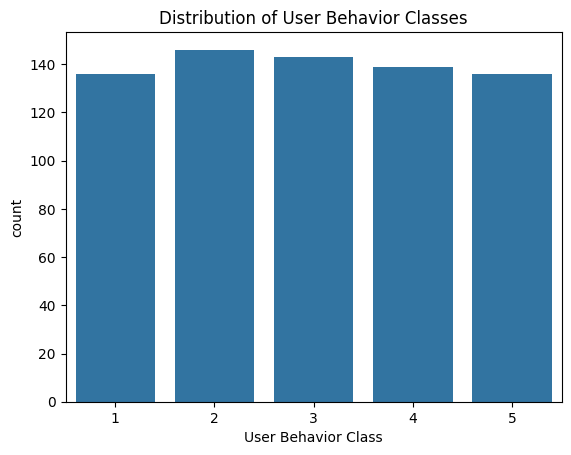

In [11]:
sns.countplot(x="User Behavior Class", data=dataset_raw)
plt.title("Distribution of User Behavior Classes")
plt.show()

Dataset is balanced across behavior classes.

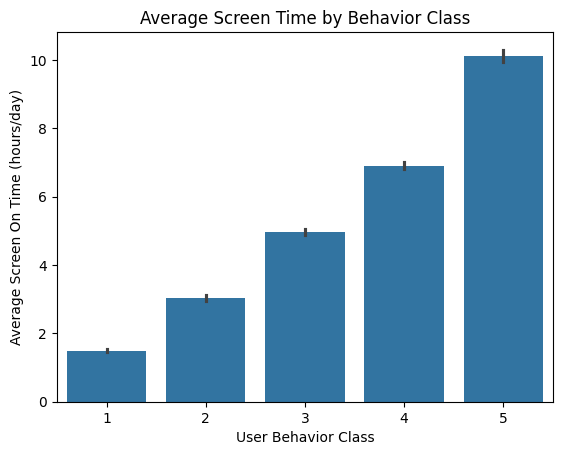

In [12]:
sns.barplot(
    x="User Behavior Class",
    y="Screen On Time (hours/day)",
    data=dataset_raw,
)

plt.title("Average Screen Time by Behavior Class")
plt.xlabel("User Behavior Class")
plt.ylabel("Average Screen On Time (hours/day)")
plt.show()

In [13]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2)

In [14]:
from sklearn.linear_model import LogisticRegression

# create the model
model = LogisticRegression()

# train the model
model.fit(X_train, y_train)

LogisticRegression()

In [15]:
y_pred = model.predict(X_test)

In [16]:
from sklearn.metrics import accuracy_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 1.0
Confusion Matrix:
 [[21  0  0  0  0]
 [ 0 34  0  0  0]
 [ 0  0 33  0  0]
 [ 0  0  0 25  0]
 [ 0  0  0  0 27]]


/tmp/ipykernel_1617/30609318.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


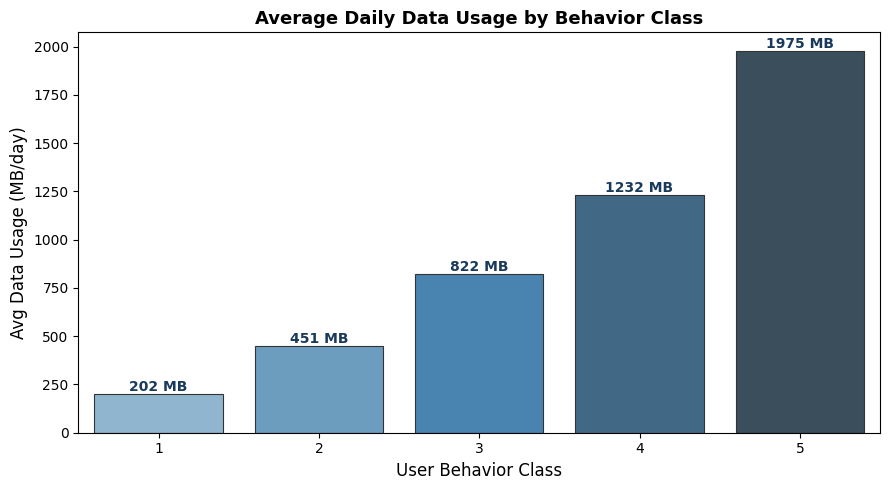

In [18]:
avg_usage = (dataset_raw.groupby('User Behavior Class')['Data Usage (MB/day)']
                 .mean().reset_index())

fig, ax = plt.subplots(figsize=(9, 5))
bars = sns.barplot(
    data=avg_usage, x='User Behavior Class', y='Data Usage (MB/day)',
    palette='Blues_d', edgecolor='#333', linewidth=0.8, ax=ax
)

for bar in bars.patches:
    ax.annotate(
        f"{bar.get_height():.0f} MB",
        (bar.get_x() + bar.get_width() / 2., bar.get_height()),
        ha='center', va='bottom', fontsize=10, fontweight='bold', color='#1a3a5c'
    )

ax.set_xlabel('User Behavior Class', fontsize=12)
ax.set_ylabel('Avg Data Usage (MB/day)', fontsize=12)
ax.set_title('Average Daily Data Usage by Behavior Class',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
